### V4, will be adding washout to see if that helps the scaling issue.


In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np      
from scipy.integrate import complex_ode

from tasks import make_static_sin_task
from encoding_masking import build_masked_input, compute_tdm_params
from Reservoirs.ELM_static import run_elm_static, ELMStaticParams
from readout import split_states_targets, fit_ridge_readout, predict_readout
from metrics import mse, nrmse
from Reservoirs.LangKobayashi import expand_virtual_nodes, simulate_lk, simulate_lk_mini, extract_R_from_E, intensities_after_theta_times, charge_at_theta_intervals 

In [2]:
def simulate_lk_W_washout(Vs, dt, Nd_delay, *, alpha, kappa, phi, p, eta, D_noise, xi, Tlk, E0=1e-3+0j, n0=0.0):

    washout = 50*20
    Vs = np.asarray(Vs, dtype=float)
    
    T_steps = Vs.size

    E_hist = np.zeros(T_steps, dtype=np.complex128)
    n_hist = np.zeros(T_steps, dtype=float)

    # delay buffer holds E(t - tau)
    delay_buf = np.full(Nd_delay, E0, dtype=np.complex128)
    di = 0 #Index pointer for delay buffer

    E, n = E0, n0
    '''
    for t in range(T_steps):
        v_slot = float(Vs[t])
        E_delay = delay_buf[di]

        E, n = rk4_step(E, n, E_delay, v_slot, dt, alpha, kappa, phi, p, eta, D_noise, xi, Tlk)

        E_hist[t] = E
        n_hist[t] = n

        delay_buf[di] = E
        di = (di + 1) % Nd_delay

    return E_hist, n_hist
    '''
    '''
    for t in range(T_steps + washout):
        
        if t < washout:
            v_slot = 0
            E_delay = delay_buf[di]

            E, n = rk4_step(E, n, E_delay, v_slot, dt, alpha, kappa, phi, p, eta, D_noise, xi, Tlk)

        #E_hist[t] = E
        # n_hist[t] = n

            delay_buf[di] = E
            di = (di + 1) % Nd_delay

        else:
            v_slot = float(Vs[t-washout])
        
            E_delay = delay_buf[di]
            E, n = rk4_step(E, n, E_delay, v_slot, dt, alpha, kappa, phi, p, eta, D_noise, xi, Tlk)

            E_hist[t-washout] = E
            n_hist[t-washout] = n

            delay_buf[di] = E
            di = (di + 1) % Nd_delay
        

    return E_hist, n_hist

    '''

    for t in range(T_steps + washout):

        if t < washout:
            v_slot = 0.0
        else:
            v_slot = float(Vs[t - washout])

        E_delay = delay_buf[di]

        E, n = rk4_step(
            E, n, E_delay, v_slot, dt,
            alpha, kappa, phi, p, eta, D_noise, xi, Tlk
        )

        # ALWAYS update delay buffer
        delay_buf[di] = E
        di = (di + 1) % Nd_delay

        # Only record after washout
        if t >= washout:
            E_hist[t - washout] = E
            n_hist[t - washout] = n

    return E_hist, n_hist


In [3]:
L = 1000
N = 20

#reservoir parameters:
p = 0.05 #normalised injection current
eta = 0.01 #input strength 
alpha = 0 #linewidth enhancemenet factor
phi = 0.0 #phase shift
TLk = 50
kappa = 0.1 
D_noise = 10**-7*0

xi = 0 #for now, this is time dependant and represents Gaussian noise.

task_seed = 0
mask_seed = 42


#g = 1.0
ridge_alpha = 0
split = 0.8

theta = 22
dt = 0.1
tau_factor = 1.41 #as per the Kathy Ludge paper.

TDM_parameters = compute_tdm_params(N, theta, dt, tau_factor)

tap_stride = TDM_parameters.tap_stride
Nd_loop = TDM_parameters.Nd_loop
print(TDM_parameters)

TDMParams(N=20, theta=22, dt=0.1, T=440, tau=620.4, Nd_loop=4400, Nd_delay=6204, tap_stride=220)


In [4]:
task = make_static_sin_task(L=L, seed=task_seed)
x, y = task.x, task.y


In [5]:
x_norm, mask, V = build_masked_input(x, N=N, rng=mask_seed) 

In [6]:
#xpandedV = expand_virtual_nodes(V, tap_stride, Nd_loop)



In [7]:
tap_stride = TDM_parameters.tap_stride  
Nd_delay = TDM_parameters.Nd_delay    
tau = TDM_parameters.tau


Vs = expand_virtual_nodes(V, tap_stride=tap_stride, Nd=Nd_loop)  
E_hist, n_hist = simulate_lk(Vs, dt, Nd_delay, alpha=alpha, kappa=kappa, phi=phi, p=p, eta=eta, D_noise=D_noise, xi=xi, Tlk=50, E0=1e-3+0j, n0=0.0)
R = extract_R_from_E(E_hist, L=L, N=N, tap_stride=tap_stride, Nd_loop=Nd_loop)
#print("R shape:", R.shape)  # should be (L, N)




In [8]:
#E_hist_wash, n_hist_wash = simulate_lk_washout(Vs, dt, Nd_delay, alpha=alpha, kappa=kappa, phi=phi, p=p, eta=eta, D_noise=D_noise, xi=xi, Tlk=50, E0=1e-3+0j, n0=0.0)
#R_wash = extract_R_from_E(E_hist_wash, L=L, N=N, tap_stride=tap_stride, Nd_loop=Nd_loop)

MSE: 0.4832856966635191
NRMSE: 0.9569026244822987


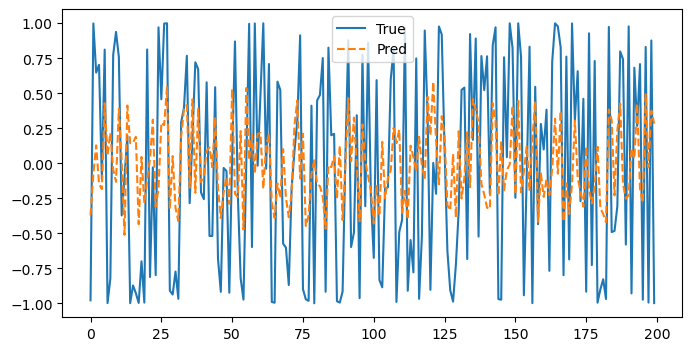

In [9]:
s = split_states_targets(R, y, split=split)
#model = fit_ridge_readout(s.R_train, s.y_train, alpha=ridge_alpha, fit_intercept=False)
model = fit_ridge_readout(s.R_train, s.y_train, alpha= 0, fit_intercept=True) # trying this to see if fit intercpet true improves performance
y_pred = predict_readout(model, s.R_test)

print("MSE:", mse(s.y_test, y_pred))
print("NRMSE:", nrmse(s.y_test, y_pred))

plt.figure(figsize=(8,4))
plt.plot(s.y_test[:2000], label="True")
plt.plot(y_pred[:2000], "--", label="Pred")
plt.legend()
plt.show()

In [10]:
#N_of_thetas = 70*5
N_of_thetas = 2000
E_hist1, n_hist1 = simulate_lk_mini(Vs, dt, Nd_delay, alpha=alpha, kappa=0, phi=phi, p=p, eta=0, D_noise=D_noise, xi=xi, Tlk=50, E0=1e-3+0j, n0=0.0, N_of_thetas=N_of_thetas, tap_stride=tap_stride)
#eta = 0 above on this as to see the effects of the laser without inputs being pumped in.
number_of_points = N_of_thetas*tap_stride
#R_mini = extract_R_from_E(E_hist1, L=L, N=, tap_stride=tap_stride, Nd_loop=Nd_loop)
#print("R shape:", R_mini.shape)  # should be (L, N)

R_mini_array = intensities_after_theta_times(E_hist1, N_of_thetas=N_of_thetas, tap_stride=tap_stride)
print("R_mini shape:", R_mini_array.shape)


R_mini shape: (2000,)


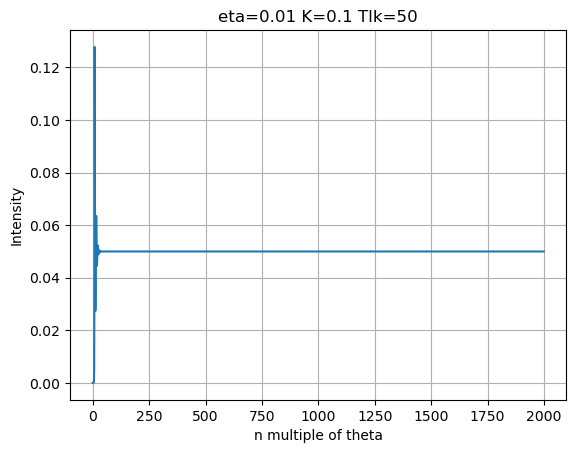

In [11]:
plt.plot(R_mini_array)
plt.xlabel("n multiple of theta")
plt.ylabel("Intensity")
plt.title("eta=0.01 K=0.1 Tlk=50")
plt.grid(True)
plt.show()

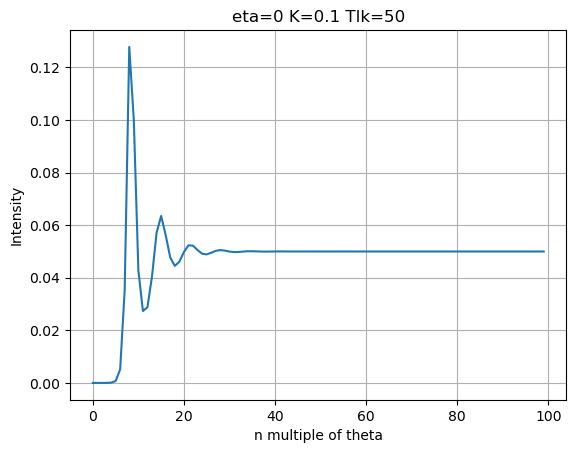

In [12]:
plt.plot(R_mini_array[0:100])
plt.xlabel("n multiple of theta")
plt.ylabel("Intensity")
plt.title("eta=0 K=0.1 Tlk=50")
plt.grid(True)
plt.show()

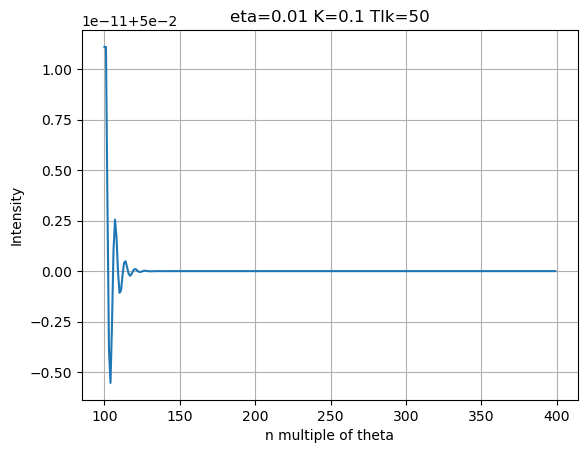

In [13]:
plt.plot(np.arange(100, 400),R_mini_array[100:400])
plt.xlabel("n multiple of theta")
plt.ylabel("Intensity")
plt.title("eta=0.01 K=0.1 Tlk=50")
plt.grid(True)
plt.show()

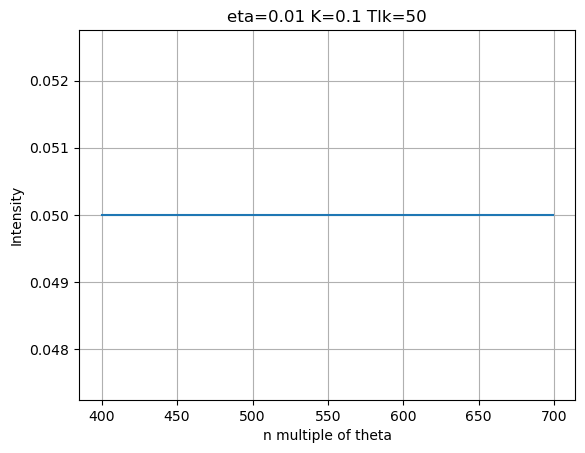

In [14]:
plt.plot(np.arange(400, 700),R_mini_array[400:700])
plt.xlabel("n multiple of theta")
plt.ylabel("Intensity")
plt.title("eta=0.01 K=0.1 Tlk=50")
plt.grid(True)
plt.show()

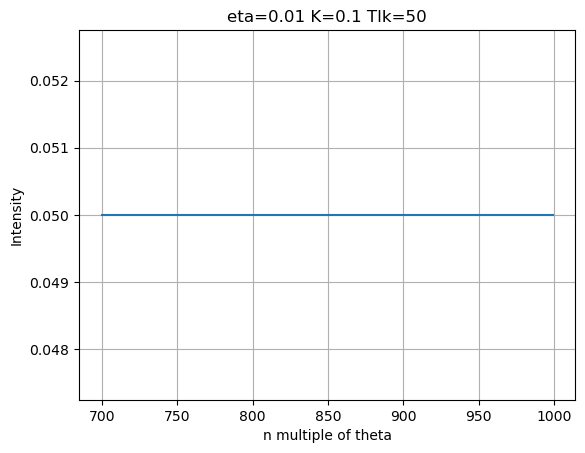

In [15]:
plt.plot(np.arange(700, 1000),R_mini_array[700:1000])
plt.xlabel("n multiple of theta")
plt.ylabel("Intensity")
plt.title("eta=0.01 K=0.1 Tlk=50")
plt.grid(True)
plt.show()

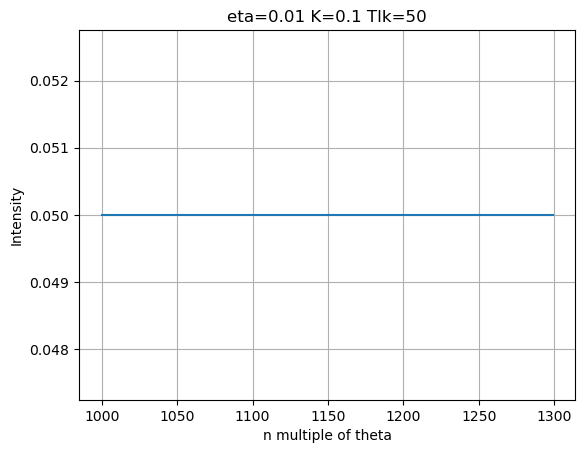

In [16]:
plt.plot(np.arange(1000, 1300),R_mini_array[1000:1300])
plt.xlabel("n multiple of theta")
plt.ylabel("Intensity")
plt.title("eta=0.01 K=0.1 Tlk=50")
plt.grid(True)
plt.show()

In [17]:
nt_at_theta_intervals = charge_at_theta_intervals(n_hist1, N_of_thetas=N_of_thetas, tap_stride=tap_stride)

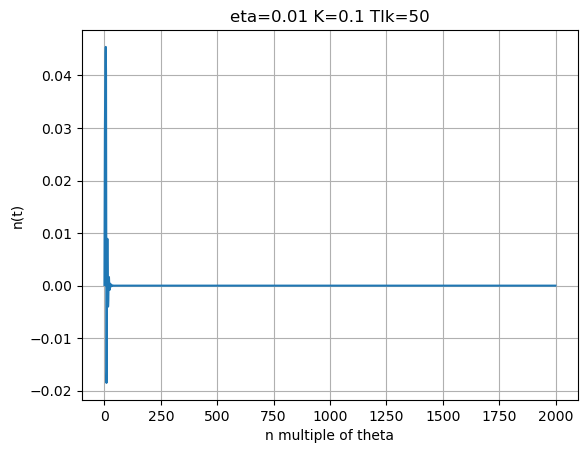

In [18]:
plt.plot(nt_at_theta_intervals)
plt.xlabel("n multiple of theta")
plt.ylabel("n(t)")
plt.title("eta=0.01 K=0.1 Tlk=50")
plt.grid(True)
plt.show()